In [1]:
import os

import numpy as np
import pandas as pd
def read_file(file_path_url):
  return np.loadtxt(file_path_url,delimiter="\t")

# fordA_test.csv, fordA_train.csv 가 없으면 다운로드
if not (os.path.isfile("fordA_test.csv") and os.path.isfile("fordA_train.csv")):
  root_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/"

  # write csv file
  pd.DataFrame(read_file(root_url + "FordA_TRAIN.tsv")).to_csv("fordA_train.csv", index=False)
  pd.DataFrame(read_file(root_url + "FordA_TEST.tsv")).to_csv("fordA_test.csv", index=False)

train = pd.read_csv("./fordA_train.csv")
test = pd.read_csv("./fordA_test.csv")

In [2]:
df = pd.DataFrame(train)
x_train_temp = df.iloc[:,1:] # 500개의 데이터
y_train_temp = df.iloc[:,0] # 정답 데이터
df

,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,-1.0,-0.797172,-0.664392,-0.373015,0.040815,0.526936,0.984288,1.353120,1.578108,1.659251,...,1.120756,0.722417,0.362068,0.092083,-0.081268,-0.212573,-0.391456,-0.664392,-1.073796,-1.564343
1,1.0,0.804855,0.634629,0.373474,0.038343,-0.340988,-0.740860,-1.109667,-1.395357,-1.570192,...,0.386403,0.049213,-0.258138,-0.510583,-0.683647,-0.773817,-0.785255,-0.714885,-0.560443,-0.319086
2,-1.0,0.727985,0.111284,-0.499124,-1.068629,-1.578351,-1.990534,-2.302031,-2.503403,-2.585211,...,0.394463,0.463685,0.507735,0.517174,0.504588,0.476270,0.438513,0.394463,0.339400,0.255391
3,-1.0,-0.234439,-0.502157,-0.732488,-0.946128,-1.139739,-1.323336,-1.490243,-1.607077,-1.620430,...,-0.952804,-0.929437,-0.922761,-0.929437,-0.909409,-0.835970,-0.695768,-0.478790,-0.188707,0.119736
4,-1.0,-0.171328,-0.062285,0.235829,0.710396,1.239969,1.649823,1.876321,1.865535,1.703751,...,0.776188,0.725496,0.697453,0.731967,0.808545,0.839823,0.733046,0.437520,-0.026585,-0.602213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3596,-1.0,0.196022,-0.070102,-0.336226,-0.516799,-0.555282,-0.442793,-0.221369,0.025217,0.233320,...,1.715205,1.129082,0.528158,-0.039020,-0.573043,-1.061479,-1.514392,-1.934743,-2.316612,-2.603753
3597,1.0,0.041994,0.422255,0.740529,0.975426,1.109891,1.137270,1.058349,0.894955,0.671224,...,-0.463329,-0.392667,-0.333749,-0.316543,-0.340299,-0.392876,-0.450805,-0.482609,-0.467769,-0.393755
3598,-1.0,-0.570054,-0.333165,-0.293519,-0.425344,-0.590869,-0.615648,-0.348033,0.275412,1.153586,...,0.902821,0.579700,0.157463,-0.353980,-0.885246,-1.314421,-1.512655,-1.393714,-0.942733,-0.270722
3599,1.0,2.006732,2.079150,2.022036,1.867560,1.648112,1.379446,1.093717,0.784057,0.434150,...,1.268671,1.148971,0.928088,0.634953,0.311682,-0.007376,-0.270543,-0.432145,-0.441231,-0.280709


정상 데이터의 개수:  1755 비정상 데이터의 개수:  1846


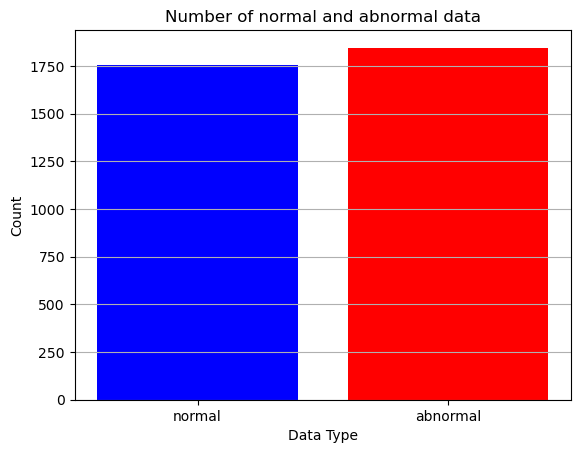

In [3]:
import matplotlib.pyplot as plt
normal_x = x_train_temp[y_train_temp == 1] # 정상 데이터만
abnormal_x = x_train_temp[y_train_temp == -1] # 비정상 데이터만

normal_x = normal_x.reset_index(drop=True)
normal_x.shape[1]
print("정상 데이터의 개수: ", normal_x.shape[0], "비정상 데이터의 개수: ", abnormal_x.shape[0])
# 정상 데이터와 비정상 데이터의 갯수 비교 시각화
plt.bar(["normal", "abnormal"], [normal_x.shape[0], abnormal_x.shape[0]], color=['blue', 'red'])
plt.title("Number of normal and abnormal data")
plt.xlabel("Data Type")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()


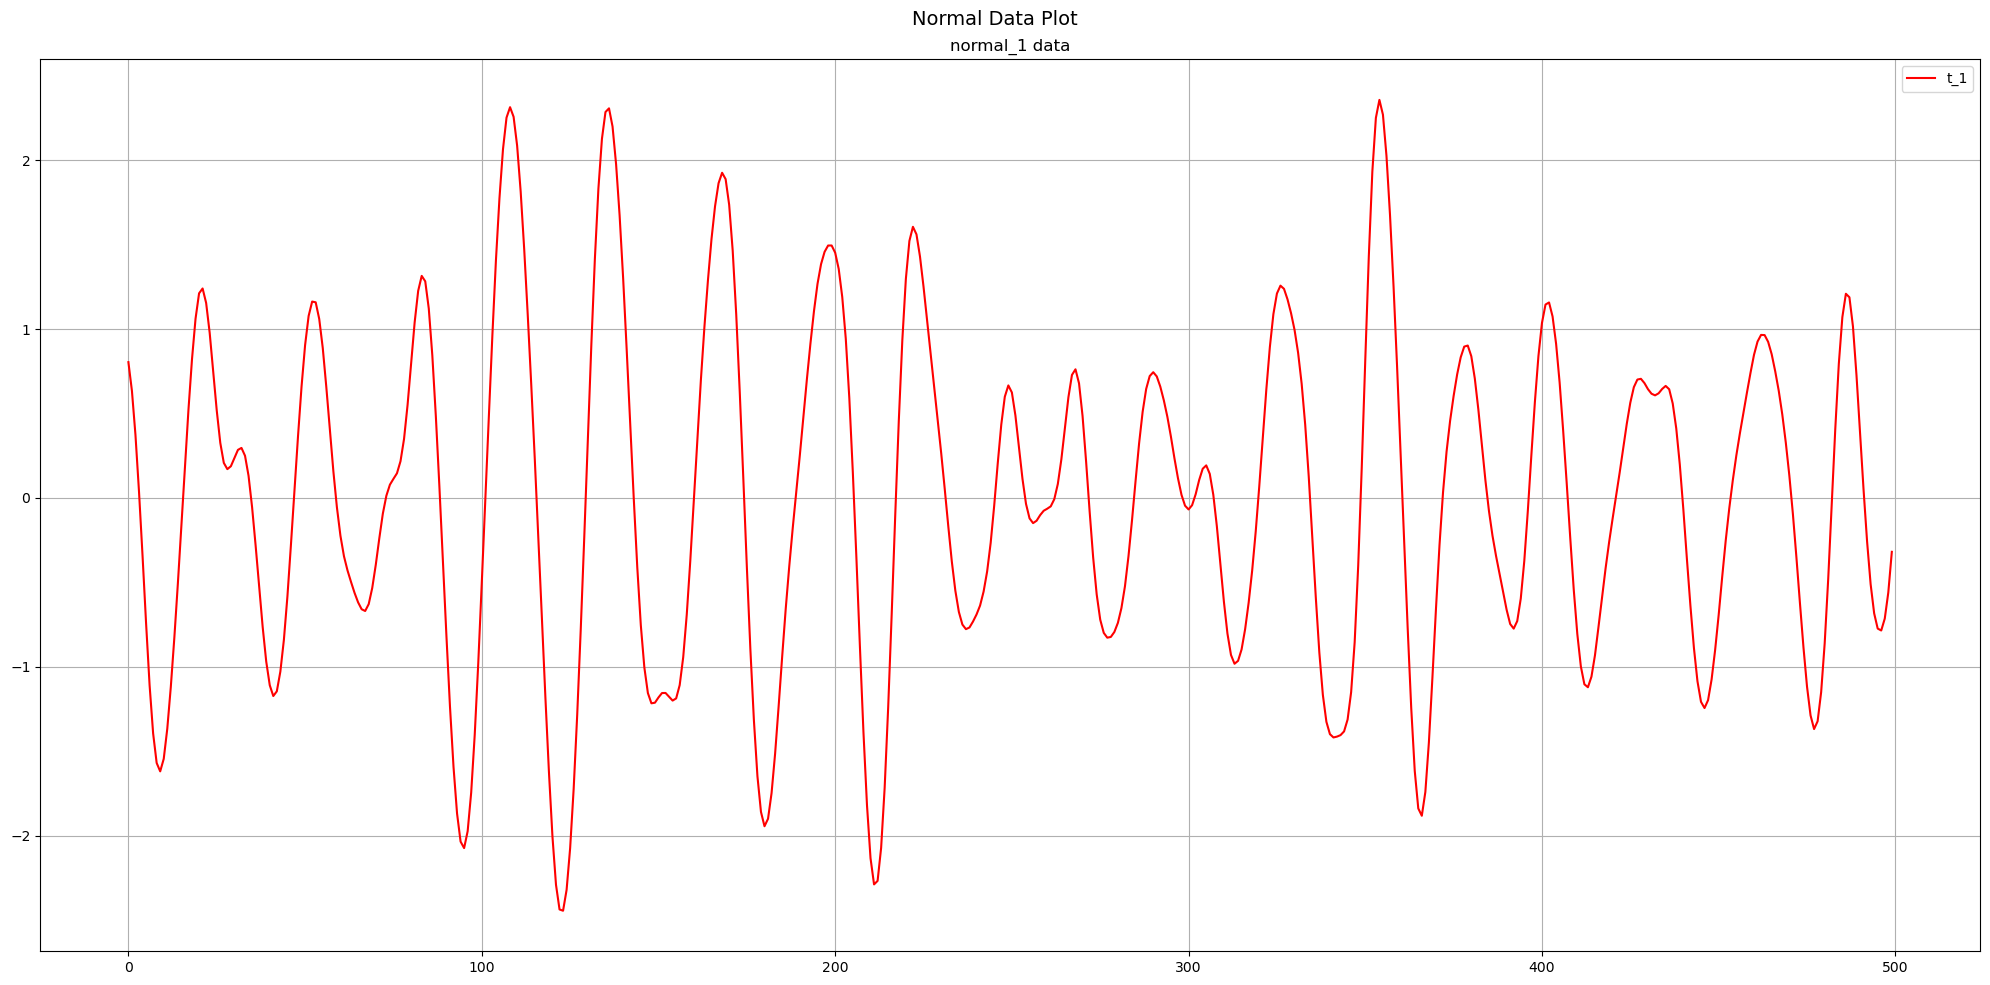

In [8]:

import matplotlib.pyplot as plt

# normal_x 데이터 시각화
fig, axes = plt.subplots(1, 1, figsize=(20, 10), sharex=True)
for i in range(1):
    axes.plot(normal_x.to_numpy()[i],color='red', label="t_{}".format(i+1))
    # axes[i].scatter(range(normal_x.shape[1]), normal_x.to_numpy()[i], color='blue', label="t_{}".format(i+1))
    axes.set_title("normal_{} data".format(i+1))
    axes.legend()
    axes.grid(True)

plt.suptitle("Normal Data Plot", fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipykernel_10538/3527780829.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


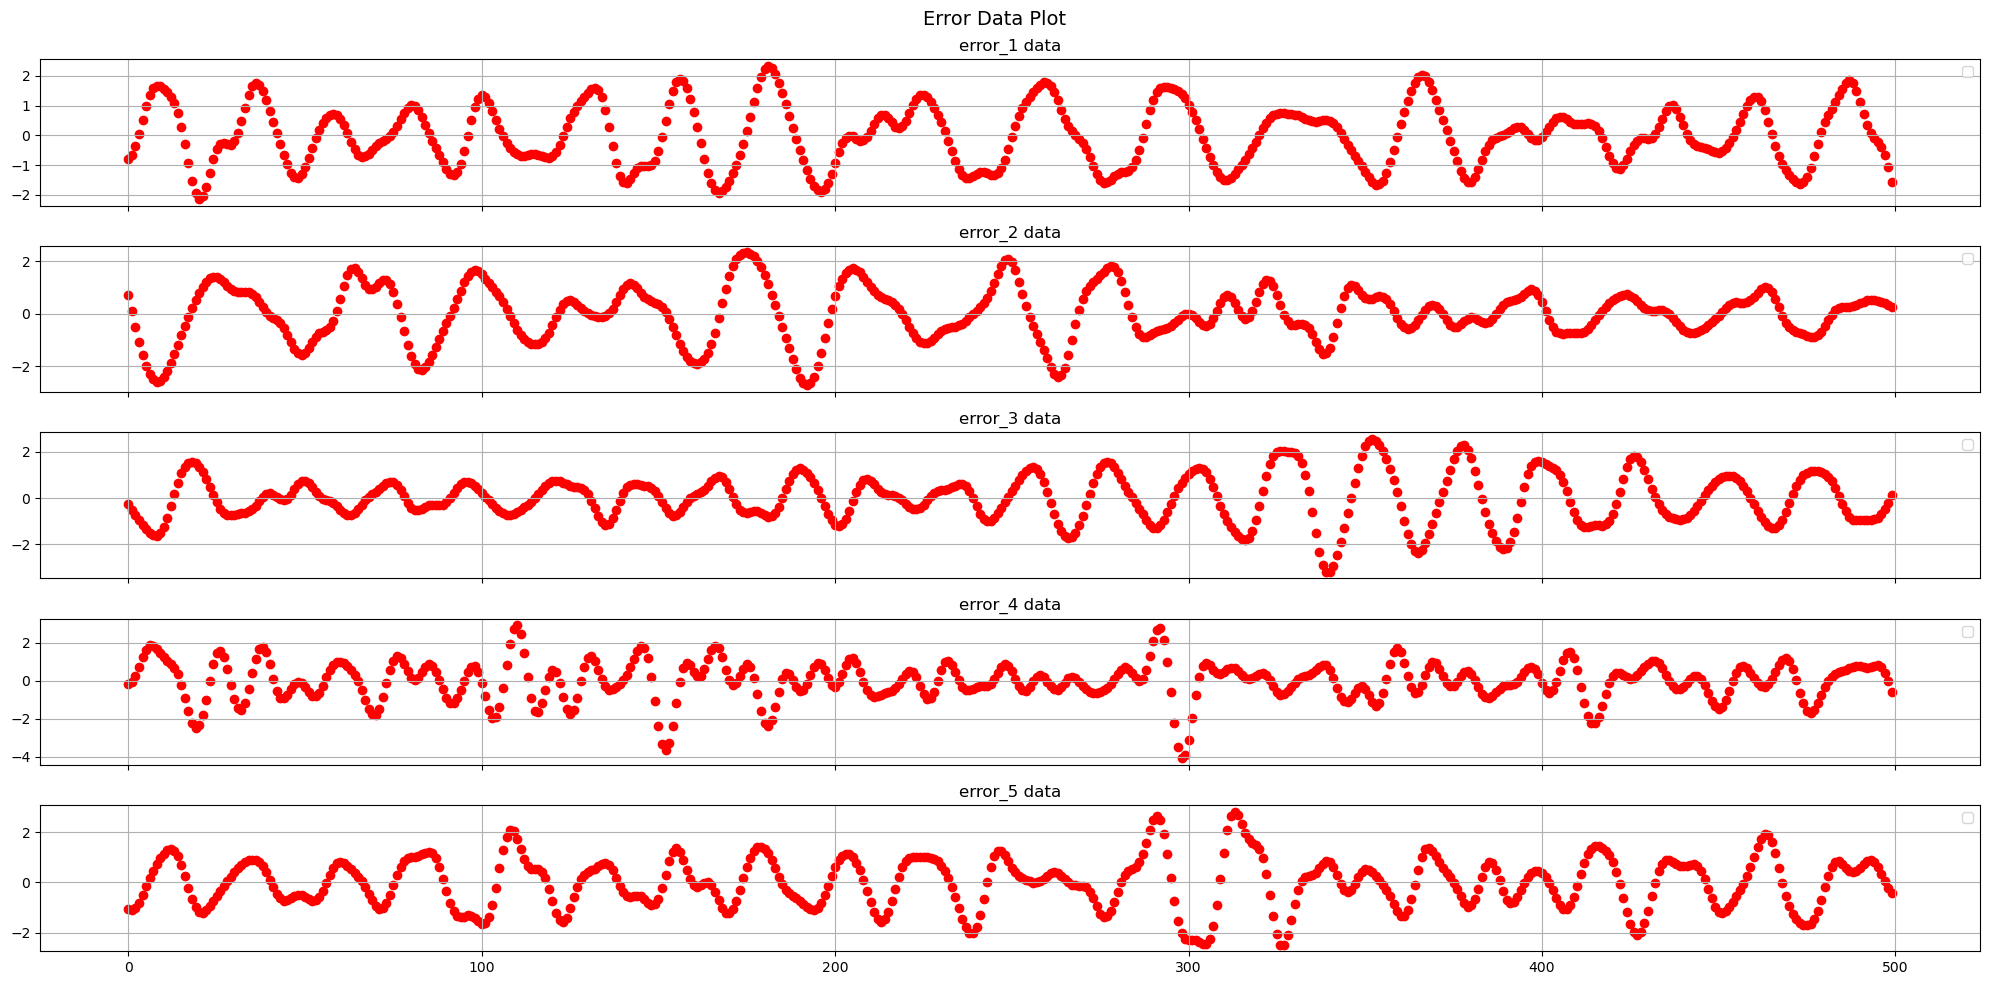

In [5]:

import matplotlib.pyplot as plt

# abnormal_x 데이터 시각화
fig, axes = plt.subplots(5, 1, figsize=(20, 10), sharex=True)
for i in range(5):
    axes[i].scatter(range(abnormal_x.shape[1]), abnormal_x.to_numpy()[i], color='red')
    axes[i].set_title("error_{} data".format(i+1))
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle("Error Data Plot", fontsize=14)
plt.tight_layout()
plt.show()


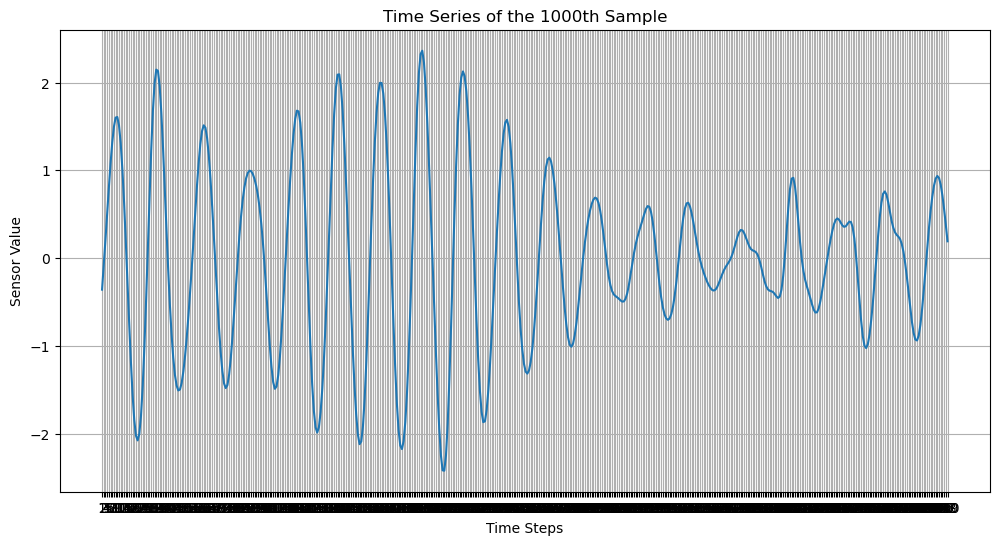

In [6]:
import matplotlib.pyplot as plt

# Plot the time series for the 1000th sample (row 1000), excluding the label column (index 0).
plt.figure(figsize=(12, 6))
plt.plot(df.iloc[3000, 1:])
plt.xlabel("Time Steps")
plt.ylabel("Sensor Value")
plt.title("Time Series of the 1000th Sample")
plt.grid(True)
plt.show()

### 데이터 스케일링 (StandardScaler 적용)

SVD 및 t-SNE와 같은 거리 기반 알고리즘은 데이터의 스케일에 민감합니다. 각 특성의 평균을 0, 표준편차를 1로 조정하는 `StandardScaler`를 적용하여 모든 특성이 분석에 동일하게 기여하도록 합니다.

In [14]:
#정규화 Robust Scaler
from sklearn.preprocessing import StandardScaler
all_x = pd.concat([normal_x, abnormal_x])
all_y = pd.concat([y_train_temp[y_train_temp == 1], y_train_temp[y_train_temp == -1]])
print(all_y)
scaler = StandardScaler()
all_x_scaled = scaler.fit_transform(all_x.T).T

print("Scaled data shape:", all_x_scaled.shape)

1       1.0
5       1.0
6       1.0
7       1.0
8       1.0
       ... 
3591   -1.0
3592   -1.0
3596   -1.0
3598   -1.0
3600   -1.0
Name: 0, Length: 3601, dtype: float64
Scaled data shape: (3601, 500)


In [8]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 0) 데이터 준비
# -----------------------------
# all_x: 원본(비스케일) 데이터가 이미 있다고 가정
X_raw = np.asarray(all_x, dtype=float)

# SVD용 스케일 데이터 (원하면 StandardScaler 대신 현재 방식(RobustScaler)로 바꿔도 됨)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 비교할 성분 개수
k = 10

# -----------------------------
# 1) 요청하신 비교:
#    PCA(비스케일 원본) vs SVD(스케일 데이터)
# -----------------------------
# PCA on raw
pca_raw = PCA(n_components=k)
Z_pca_raw = pca_raw.fit_transform(X_raw)
evr_pca_raw = pca_raw.explained_variance_ratio_

# SVD on scaled (PCA와 수학적으로 맞추기 위해 중심화 후 SVD)
X_scaled_centered = X_scaled - X_scaled.mean(axis=0)
U_s, S_s, Vt_s = np.linalg.svd(X_scaled_centered, full_matrices=False)
Z_svd_scaled = U_s[:, :k] * S_s[:k]
evr_svd_scaled = (S_s**2) / np.sum(S_s**2)
evr_svd_scaled_k = evr_svd_scaled[:k]

# 부호 정렬(sign ambiguity) 보정 후 성분별 상관계수
comp_corr = []
for i in range(k):
    a = Z_pca_raw[:, i]
    b = Z_svd_scaled[:, i]
    c = np.corrcoef(a, b)[0, 1]
    if c < 0:
        Z_svd_scaled[:, i] *= -1
        c = -c
    comp_corr.append(c)

print("=== 비교 1: PCA(raw) vs SVD(scaled) ===")
print("성분별 상관계수(절대):", np.round(comp_corr, 4))
print("평균 상관:", np.mean(comp_corr).round(4))

same_evr = np.allclose(evr_pca_raw, evr_svd_scaled_k, atol=1e-5)
print("설명분산비 동일 여부:", same_evr)
print("PCA(raw) EVR[:k]:", np.round(evr_pca_raw, 4))
print("SVD(scaled) EVR[:k]:", np.round(evr_svd_scaled_k, 4))

# -----------------------------
# 2) 참고 검증:
#    같은 전처리(둘 다 scaled)일 때 PCA와 SVD가 일치하는지
# -----------------------------
pca_scaled = PCA(n_components=k)
Z_pca_scaled = pca_scaled.fit_transform(X_scaled)
evr_pca_scaled = pca_scaled.explained_variance_ratio_

# 이미 위에서 X_scaled_centered에 대해 SVD 수행함
Z_svd_scaled_ref = U_s[:, :k] * S_s[:k]
evr_svd_scaled_ref = (S_s**2) / np.sum(S_s**2)
evr_svd_scaled_ref_k = evr_svd_scaled_ref[:k]

corr_ref = []
for i in range(k):
    a = Z_pca_scaled[:, i]
    b = Z_svd_scaled_ref[:, i]
    c = np.corrcoef(a, b)[0, 1]
    if c < 0:
        c = -c
    corr_ref.append(c)

same_evr_ref = np.allclose(evr_pca_scaled, evr_svd_scaled_ref_k, atol=1e-5)

print("\n=== 비교 2(참고): PCA(scaled) vs SVD(scaled-centered) ===")
print("성분별 상관계수(절대):", np.round(corr_ref, 6))
print("평균 상관:", np.mean(corr_ref).round(6))
print("설명분산비 동일 여부:", same_evr_ref)

=== 비교 1: PCA(raw) vs SVD(scaled) ===
성분별 상관계수(절대): [0.999  0.9991 0.9975 0.999  0.9977 0.9983 0.9937 0.9937 0.9941 0.9932]
평균 상관: 0.9965
설명분산비 동일 여부: False
PCA(raw) EVR[:k]: [0.0873 0.085  0.066  0.0646 0.0497 0.0479 0.0341 0.0336 0.0283 0.0264]
SVD(scaled) EVR[:k]: [0.088  0.086  0.0657 0.0645 0.0493 0.0474 0.034  0.0333 0.0282 0.0266]

=== 비교 2(참고): PCA(scaled) vs SVD(scaled-centered) ===
성분별 상관계수(절대): [1.       1.       1.       1.       1.       1.       1.       1.
 0.999999 1.      ]
평균 상관: 1.0
설명분산비 동일 여부: True


### 스케일링 후 SVD 재수행

스케일링된 데이터에 SVD를 다시 적용하여 설명력 변화를 확인합니다.

(3601, 500)


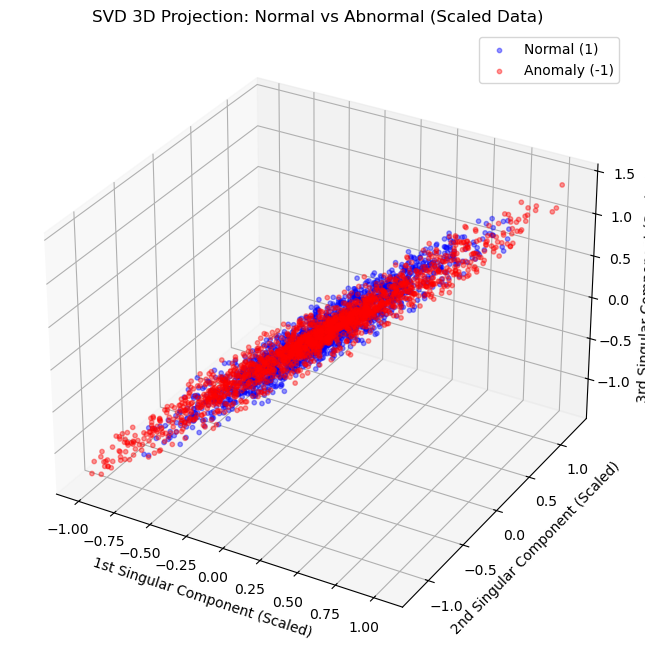

In [15]:
from numpy.linalg import svd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 차원 수
k = 3
U_scaled, S_scaled, Vt_scaled = svd(all_x_scaled, full_matrices=False)
U_3d_scaled = U_scaled[:, :k]
# 3차원 latent 좌표(시각화용)
Z_3d = U_scaled[:, :k] * S_scaled[:k]
# 3차원 성분만 남긴 복원 데이터(denoised reconstruction)
X_3d_recon = Z_3d @ Vt_scaled[:k, :]
X_k = U_scaled[:,:k] @ np.diag(S_scaled[:k]) @ Vt_scaled[:k,:]

print(X_3d_recon.shape)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d_recon[all_y == 1, 0], X_3d_recon[all_y == 1, 1], X_3d_recon[all_y == 1, 2],
           c='blue', alpha=0.4, label='Normal (1)', s=10)
ax.scatter(X_3d_recon[all_y == -1, 0], X_3d_recon[all_y == -1, 1], X_3d_recon[all_y == -1, 2],
           c='red', alpha=0.4, label='Anomaly (-1)', s=10)
ax.set_xlabel('1st Singular Component (Scaled)')
ax.set_ylabel('2nd Singular Component (Scaled)')
ax.set_zlabel('3rd Singular Component (Scaled)')
ax.set_title('SVD 3D Projection: Normal vs Abnormal (Scaled Data)')
ax.legend()
plt.show()

# explained_scaled = S_scaled**2 / np.sum(S_scaled**2)
# print(f"1st component 설명력 (Scaled): {explained_scaled[0]*100:.2f}%")
# print(f"2nd component 설명력 (Scaled): {explained_scaled[1]*100:.2f}%")
# print(f"누적 설명력 (상위 2개, Scaled): {np.sum(explained_scaled[:2])*100:.2f}%")

3D reconstructed data shape: (3601, 500)
3D projection shape: (3601, 3)


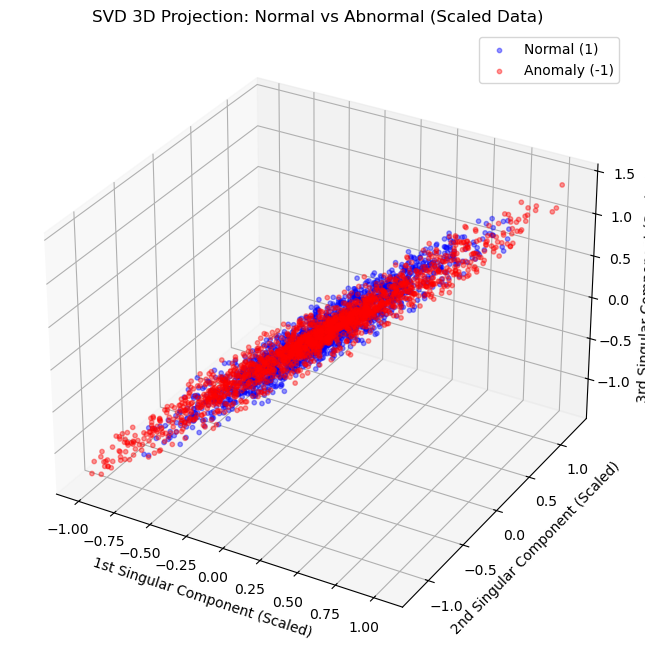

In [12]:
# 3차원(상위 3개 특이성분)만 사용한 재구성
from mpl_toolkits.mplot3d import Axes3D

U_3d_scaled = U_scaled[:, :3]
S_3d_scaled = np.diag(S_scaled[:3])
Vt_3d_scaled = Vt_scaled[:3, :]

result_3d = U_3d_scaled @ S_3d_scaled @ Vt_3d_scaled
print("3D reconstructed data shape:", result_3d.shape)
print("3D projection shape:", U_3d_scaled.shape)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(result_3d[all_y == 1, 0], result_3d[all_y == 1, 1], result_3d[all_y == 1, 2],
           c='blue', alpha=0.4, label='Normal (1)', s=10)
ax.scatter(result_3d[all_y == -1, 0], result_3d[all_y == -1, 1], result_3d[all_y == -1, 2],
           c='red', alpha=0.4, label='Anomaly (-1)', s=10)
ax.set_xlabel('1st Singular Component (Scaled)')
ax.set_ylabel('2nd Singular Component (Scaled)')
ax.set_zlabel('3rd Singular Component (Scaled)')
ax.set_title('SVD 3D Projection: Normal vs Abnormal (Scaled Data)')
ax.legend()
plt.show()

In [ ]:
# 인터랙티브 3D 시각화 (회전/확대/축소 가능)
import pandas as pd

try:
    import plotly.express as px
except ImportError:
    raise ImportError("plotly가 필요합니다. `pip install plotly` 후 다시 실행하세요.")

plot_df = pd.DataFrame({
    'PC1': Z_3d[:, 0],
    'PC2': Z_3d[:, 1],
    'PC3': Z_3d[:, 2],
    'label': all_y.astype(str).values
})

fig = px.scatter_3d(
    plot_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='label',
    color_discrete_map={'1': 'blue', '-1': 'red'},
    opacity=0.5,
    title='Interactive SVD 3D Projection (Top 3 Components)'
 )

fig.update_traces(marker=dict(size=3))
fig.update_layout(legend_title_text='Class')
fig.show()

### SVD와 PCA의 수학적 연관성 확인

중심화된 데이터에 대해 SVD의 특이값($\sigma$)과 PCA의 설명 분산(Explained Variance)이 일치하는지 확인합니다. PCA의 `explained_variance_`는 $S^2 / (n-1)$과 같습니다.

In [12]:
from sklearn.decomposition import PCA
import numpy as np
from numpy.linalg import svd

# 1. 데이터를 명시적으로 중심화 (PCA의 기본 동작과 일치시킴)
all_x_centered = all_x_scaled - np.mean(all_x_scaled, axis=0)

# 2. 중심화된 데이터로 SVD 재수행
U_c, S_c, Vt_c = svd(all_x_centered, full_matrices=False)

# 3. SVD 특이값을 분산으로 변환 (n_samples - 1로 나눔)
n_samples = all_x_centered.shape[0]
svd_variance = (S_c**2) / (n_samples - 1)

# 4. PCA 결과와 비교
pca_full = PCA().fit(all_x_scaled)

print(f"SVD(중심화 후) 첫 번째 성분 분산: {svd_variance[0]:.4f}")
print(f"PCA 객체 첫 번째 성분 분산: {pca_full.explained_variance_[0]:.4f}")

# 오차 범위 내 일치 여부 확인
np.testing.assert_allclose(svd_variance[:50], pca_full.explained_variance_[:50], atol=1e-5)
print("\n결과: 데이터 중심화 후 SVD의 특이값과 PCA의 분산이 정확히 일치함을 확인했습니다.")

SVD(중심화 후) 첫 번째 성분 분산: 23.6533
PCA 객체 첫 번째 성분 분산: 23.6533

결과: 데이터 중심화 후 SVD의 특이값과 PCA의 분산이 정확히 일치함을 확인했습니다.


### Singular Value Decay Visualization (Scree Plot)

SVD를 통해 얻은 특이값($σ$)의 분포를 시각화합니다. 특이값이 급격히 떨어지지 않고 완만하게 유지된다는 것은 데이터의 정보가 소수의 주성분에 집중되어 있지 않음을 의미하며, 이는 2차원 투영만으로는 데이터를 충분히 설명하기 어려운 기술적 근거가 됩니다.

NameError: name 'S_scaled' is not defined

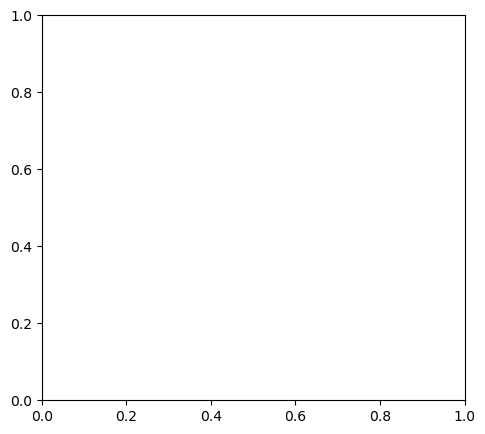

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 특이값 시각화 (Singular Values)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(S_scaled, marker='o', markersize=2, linestyle='-')
plt.title('Singular Value Spectrum')
plt.xlabel('Component Index')
plt.ylabel('Singular Value ($σ$)')
plt.grid(True, alpha=0.3)

# 2. 누적 설명 분산 비율 시각화 (Cumulative Explained Variance Ratio)
explained_variance_ratio = (S_scaled**2) / np.sum(S_scaled**2)
cumulative_variance = np.cumsum(explained_variance_ratio)

# 90% 지점 계산
n_90 = np.where(cumulative_variance >= 0.9)[0][0] + 1

plt.subplot(1, 2, 2)
plt.plot(cumulative_variance, drawstyle='steps-post', color='red')
plt.axhline(y=0.9, color='k', linestyle='--', alpha=0.5, label='90% Threshold')
plt.axvline(x=n_90, color='blue', linestyle=':', alpha=0.7, label=f'n={n_90}') # 세로선 추가
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Ratio')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 주요 수치 출력
print(f"상위 2개 성분의 누적 설명력: {cumulative_variance[1]*100:.2f}%")
print(f"90% 설명력을 확보하기 위해 필요한 성분 개수: {n_90}개")

### 다차원 PCA (90% 설명력) + KNN 성능 평가

2차원 투영의 한계를 극복하기 위해, 누적 설명력 90%를 달성하는 데 필요한 주성분 개수(47개)를 사용하여 KNN 성능을 재평가합니다.

In [14]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import robust_scale

# 0. 테스트 데이터 준비 (아직 정의되지 않은 경우 여기서 정의)
x_test = test.iloc[:, 1:]
y_test = test.iloc[:, 0]
x_test_scaled = robust_scale(x_test, axis=1)

# 1. 90% 설명력을 확보하는 성분 개수 설정 (이전 셀 결과 기반)
n_components_90 = np.where(cumulative_variance >= 0.9)[0][0] + 1
print(f"사용할 주성분 개수: {n_components_90}")

# 2. 학습 데이터에서 상위 n개 성분 추출 (U * S 활용)
# SVD 결과인 U_scaled는 (Samples, Components) 형태이며 이미 S를 포함하는 비율로 정규화되어 있음
# 원본 데이터를 주성분 축에 투영.
X_train_pca_multi = U_scaled[:, :n_components_90] * S_scaled[:n_components_90]

# 3. 테스트 데이터 PCA 투영
# 이미 계산된 Vt_scaled(고유벡터)를 사용하여 테스트 데이터를 투영
X_test_pca_multi = np.dot(x_test_scaled, Vt_scaled[:n_components_90].T)

# 4. KNN 학습 및 예측
knn_multi = KNeighborsClassifier(n_neighbors=5)
knn_multi.fit(X_train_pca_multi, all_y)

y_pred_multi = knn_multi.predict(X_test_pca_multi)

# 5. 결과 출력
accuracy_multi = accuracy_score(y_test, y_pred_multi)
print(f"PCA ({n_components_90}D) + KNN Test Accuracy: {accuracy_multi*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_multi))


사용할 주성분 개수: 47
PCA (47D) + KNN Test Accuracy: 70.00%

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.65      0.92      0.76       681
         1.0       0.84      0.47      0.60       639

    accuracy                           0.70      1320
   macro avg       0.74      0.69      0.68      1320
weighted avg       0.74      0.70      0.68      1320



### 47D PCA + KNN 성능 시각화 (장표용)

90%의 설명력을 가진 47개의 주성분을 활용한 KNN 모델의 분류 결과를 시각화합니다. 예측의 정확도뿐만 아니라 어떤 클래스에서 오답이 발생하는지 직관적으로 확인합니다.

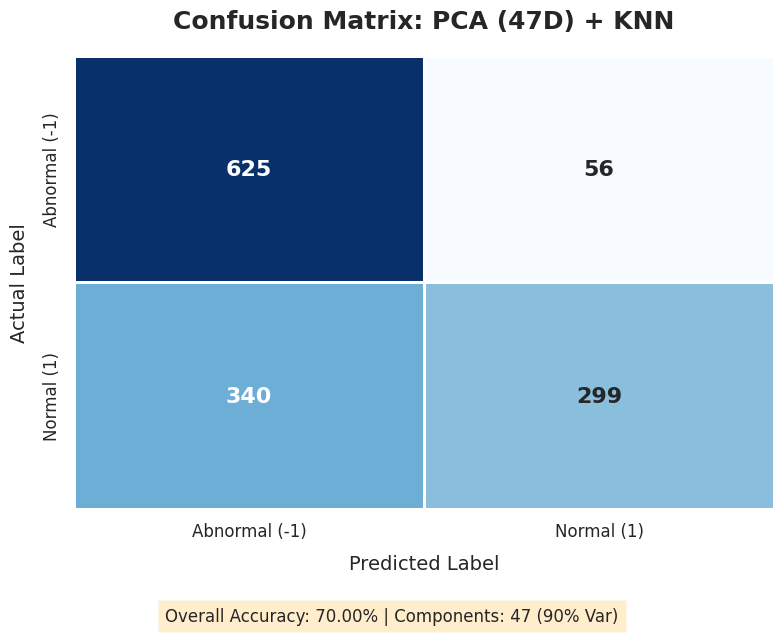

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Confusion Matrix 계산
cm = confusion_matrix(y_test, y_pred_multi)

# 2. 시각화 설정
plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

# 히트맵 그리기
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 annot_kws={"size": 16, "weight": "bold"},
                 cbar=False, linewidths=2, linecolor='white')

# 라벨 및 타이틀 설정
plt.title('Confusion Matrix: PCA (47D) + KNN', fontsize=18, pad=20, weight='bold')
plt.xlabel('Predicted Label', fontsize=14, labelpad=10)
plt.ylabel('Actual Label', fontsize=14, labelpad=10)

# 틱 라벨 수정 (-1, 1 -> Abnormal, Normal)
ax.set_xticklabels(['Abnormal (-1)', 'Normal (1)'], fontsize=12)
ax.set_yticklabels(['Abnormal (-1)', 'Normal (1)'], fontsize=12, va='center')

# 하단에 요약 정보 추가
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
plt.figtext(0.5, -0.05, f"Overall Accuracy: {accuracy*100:.2f}% | Components: 47 (90% Var)",
            ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

plt.tight_layout()
plt.show()

### Explained Variance Threshold(80%~99%)에 따른 정확도 변화 분석

누적 설명 분산량(Cumulative Explained Variance)의 임계치를 0.80에서 0.99까지 변화시키며, 각 임계치를 충족하기 위해 필요한 주성분의 수와 그에 따른 KNN 모델의 정확도 변화를 측정합니다.

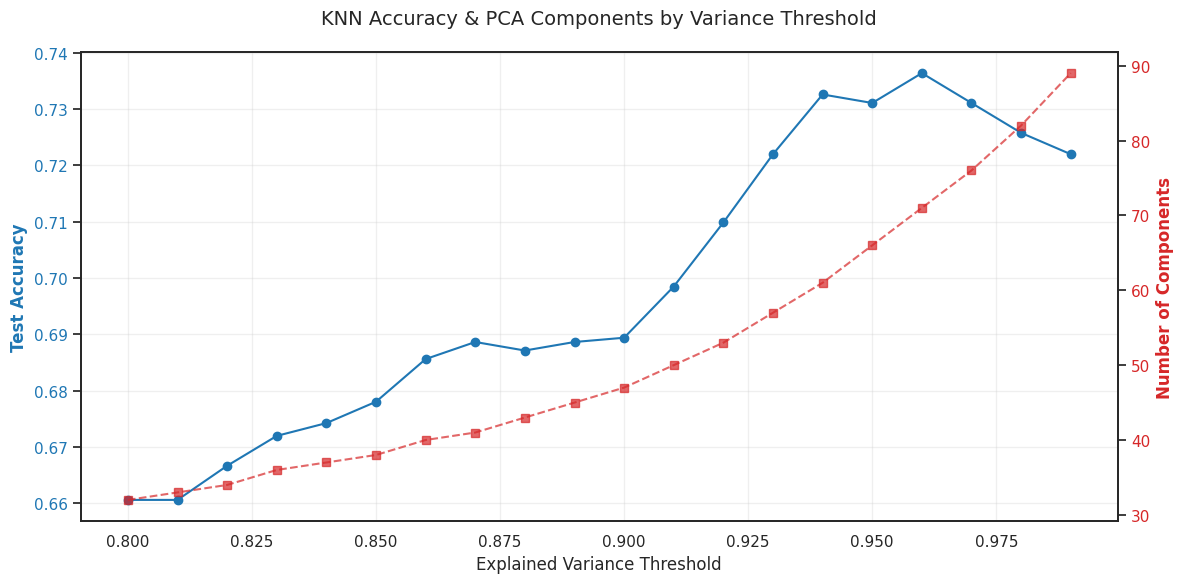

Threshold: 0.80 | Components:  32 | Accuracy: 66.06%
Threshold: 0.85 | Components:  38 | Accuracy: 67.80%
Threshold: 0.90 | Components:  47 | Accuracy: 68.94%
Threshold: 0.95 | Components:  66 | Accuracy: 73.11%
Threshold: 0.96 | Components:  71 | Accuracy: 73.64%
Threshold: 0.97 | Components:  76 | Accuracy: 73.11%
Threshold: 0.98 | Components:  82 | Accuracy: 72.58%
Threshold: 0.99 | Components:  89 | Accuracy: 72.20%


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. 설정할 임계치 범위 (80% ~ 99%)
thresholds = np.arange(0.80, 1.00, 0.01)
results_n_components = []
results_accuracy = []

# 2. 루프를 돌며 각 임계치별 성능 측정
for thr in thresholds:
    # 해당 임계치를 넘기 위한 성분 개수 계산
    n_comp = np.where(cumulative_variance >= thr)[0][0] + 1
    results_n_components.append(n_comp)

    # 학습/테스트 데이터 투영 (Vt_scaled 활용)
    V_subset = Vt_scaled[:n_comp].T
    X_train_pca = np.dot(all_x_scaled, V_subset)
    X_test_pca = np.dot(x_test_scaled, V_subset)

    # KNN 학습 및 예측
    knn = KNeighborsClassifier(n_neighbors=15) # 최적화 시 찾았던 k=15 사용
    knn.fit(X_train_pca, all_y)
    y_pred = knn.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)
    results_accuracy.append(acc)

# 3. 결과 시각화
fig, ax1 = plt.subplots(figsize=(12, 6))

# Accuracy 축
color1 = 'tab:blue'
ax1.set_xlabel('Explained Variance Threshold')
ax1.set_ylabel('Test Accuracy', color=color1, fontsize=12, fontweight='bold')
ax1.plot(thresholds, results_accuracy, color=color1, marker='o', label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# n_components 축 (이중 축 사용)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Number of Components', color=color2, fontsize=12, fontweight='bold')
ax2.plot(thresholds, results_n_components, color=color2, linestyle='--', marker='s', alpha=0.7, label='# of Components')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('KNN Accuracy & PCA Components by Variance Threshold', fontsize=14, pad=20)
fig.tight_layout()
plt.show()

# 데이터 요약 출력
for t, n, a in zip(thresholds, results_n_components, results_accuracy):
    if int(t*100) % 5 == 0 or t >= 0.95:
        print(f"Threshold: {t:.2f} | Components: {n:3d} | Accuracy: {a*100:.2f}%")

### PCA + KNN 하이퍼파라미터 최적화 (성능 극대화)

단순히 90% 설명력이 아닌, 성분 개수(n_components)와 KNN의 이웃 수(n_neighbors)를 다양하게 조합하여 차원 축소 기반 모델의 한계치를 테스트합니다.

최적 파라미터: {'n_components': 70, 'k': 15}
최고 정확도: 73.41%


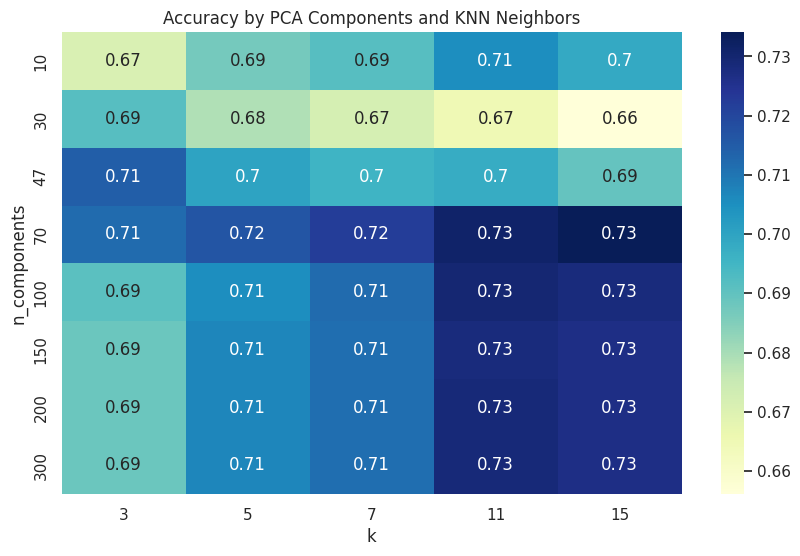

In [17]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 다양한 성분 개수에 대해 루프 수행
components_range = [10, 30, 47, 70, 100, 150, 200, 300]
best_overall_acc = 0
best_params = {}


results = []

for n in components_range:
    # PCA 투영
    V_subset = Vt_scaled[:n].T
    X_train_pca = np.dot(all_x_scaled, V_subset)
    X_test_pca = np.dot(x_test_scaled, V_subset)

    # KNN 이웃 수 최적화
    for k in [3, 5, 7, 11, 15]:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_pca, all_y)
        y_pred = knn.predict(X_test_pca)
        acc = accuracy_score(y_test, y_pred)

        results.append({'n_components': n, 'k': k, 'accuracy': acc})

        if acc > best_overall_acc:
            best_overall_acc = acc
            best_params = {'n_components': n, 'k': k}

# 결과 출력
print(f"최적 파라미터: {best_params}")
print(f"최고 정확도: {best_overall_acc*100:.2f}%")

# 시각화
import pandas as pd
res_df = pd.DataFrame(results)
pivot_df = res_df.pivot(index='n_components', columns='k', values='accuracy')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, cmap='YlGnBu')
plt.title('Accuracy by PCA Components and KNN Neighbors')
plt.show()


### PCA (주성분 분석) 수행

SVD와 유사하게 선형 차원 축소 기법인 PCA를 적용하여 2차원 투영 결과를 확인합니다. 이미 `StandardScaler`를 통해 데이터가 중심화되어 있으므로, PCA 결과는 SVD와 매우 유사할 것으로 예상됩니다.

### 행 단위 스케일링 (Row-wise Scaling) 및 PCA 적용

각 샘플(행)의 평균을 0, 표준편차를 1로 조정하여 샘플 간의 '패턴 유사도'에 집중합니다.

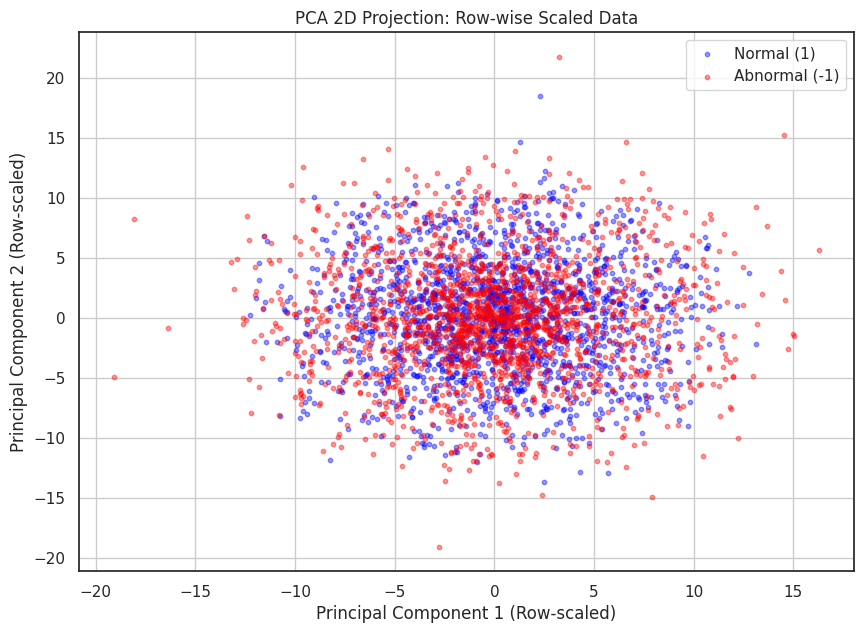

행 단위 스케일링 후 PC1 설명력: 8.35%
행 단위 스케일링 후 PC2 설명력: 8.30%


In [18]:
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. 행 단위 스케일링 수행 (axis=1을 기준으로 스케일링하기 위해 전치 후 처리)
# StandardScaler는 기본적으로 열 단위이므로, 행 단위 처리를 위해 수동 계산하거나 전치 활용
row_scaler = RobustScaler()
all_x_row_scaled = row_scaler.fit_transform(all_x.T).T

# 2. PCA 수행
pca_row = PCA(n_components=2)
X_pca_row = pca_row.fit_transform(all_x_row_scaled)

# 3. 시각화
plt.figure(figsize=(10, 7))
plt.scatter(X_pca_row[all_y == 1, 0], X_pca_row[all_y == 1, 1],
            c='blue', alpha=0.4, label='Normal (1)', s=10)
plt.scatter(X_pca_row[all_y == -1, 0], X_pca_row[all_y == -1, 1],
            c='red', alpha=0.4, label='Abnormal (-1)', s=10)
plt.xlabel('Principal Component 1 (Row-scaled)')
plt.ylabel('Principal Component 2 (Row-scaled)')
plt.title('PCA 2D Projection: Row-wise Scaled Data')
plt.legend()
plt.grid(True)
plt.show()

print(f"행 단위 스케일링 후 PC1 설명력: {pca_row.explained_variance_ratio_[0]*100:.2f}%")
print(f"행 단위 스케일링 후 PC2 설명력: {pca_row.explained_variance_ratio_[1]*100:.2f}%")

### 정상 데이터 그룹의 상관 관계 히트맵

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation for normal data, using the scaled normal data
corr_correct = normal_x_scaled.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_correct, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap for Normal Data (Label 1) - Scaled')
plt.show()

NameError: name 'normal_x_scaled' is not defined

### 비정상 데이터 그룹의 상관 관계 히트맵

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation for abnormal data, using the scaled abnormal data
corr_error = abnormal_x_scaled.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_error, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap for Abnormal Data (Label -1) - Scaled')
plt.show()

In [ ]:
# 모델 객체 생성 및 구조 확인
model = FordCNN()
print(model)

### PCA + KNN을 이용한 테스트 데이터 성능 평가

학습된 PCA 성분을 특징으로 사용하여 KNN 분류 성능을 평가합니다.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 1. 테스트 데이터 준비
x_test = test.iloc[:, 1:]
y_test = test.iloc[:, 0]

# 2. 테스트 데이터 행 단위 스케일링 (각 샘플별로 독립적으로 Robust Scaling 수행)
# 학습 시 사용했던 row_scaler를 그대로 쓰면 데이터 개수 차이로 에러가 나므로,
# 각 행(샘플) 내에서 스케일링이 되도록 처리합니다.
from sklearn.preprocessing import robust_scale
x_test_scaled = robust_scale(x_test, axis=1)

# 3. PCA 투영 (이미 학습된 pca_row 객체 사용)
x_test_pca = pca_row.transform(x_test_scaled)

# 4. KNN 분류기 생성 및 학습 (학습 데이터의 PCA 2D 특징 사용)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_pca_row, all_y)

# 5. 예측 및 평가
y_pred = knn.predict(x_test_pca)
accuracy = accuracy_score(y_test, y_pred)

print(f"PCA (2D) + KNN Test Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Abnormal', 'Normal'], yticklabels=['Abnormal', 'Normal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (PCA 2D + KNN)')
plt.show()

# FordA 데이터셋 분석 및 모델 설계 종합 보고서

## 1. 실험 배경 및 목적
FordA 데이터셋은 500개의 센서 시계열 데이터로 구성되어 있으며, 정상과 비정상 상태를 분류하는 이진 분류 문제입니다. 본 실험에서는 차원 축소 기법의 유효성을 검토하고, 복잡한 패턴 추출을 위한 딥러닝(CNN) 모델 설계의 타당성을 확보하는 것을 목적으로 합니다.

## 2. 차원 축소 및 통계적 분석 결과

### 2.1 선형 분석 (PCA)
- **결과**: PCA를 통한 2차원 투영 및 KNN 분류 정확도는 **53.64%**로 나타났습니다.
- **해석**: PC1과 PC2의 누적 설명력이 약 16.7%로 매우 낮으며, 선형적인 분산만으로는 클래스를 구분하기에 정보가 부족함을 의미합니다.

### 2.2 비선형 분석 (t-SNE)
- **결과**: t-SNE 기반의 KNN 분류 정확도는 **66.74%**로 PCA 대비 약 13% 향상되었습니다.
- **해석**: 데이터 내에 비선형적인 국소 구조(Local Structure)가 존재하며, 이를 보존할 때 분류 성능이 개선됨을 확인했습니다. 하지만 여전히 70% 미만의 정확도로 실전 적용에는 한계가 있습니다.

### 2.3 클래스 유사도 분석
- **정상/비정상 클래스 간 유사도**: 약 0.0001로 측정되었습니다.
- **결론**: 클래스 간의 코사인 유사도가 매우 낮고 두 그룹이 특징 공간에서 복잡하게 얽혀 있어, 단순한 통계량보다는 시계열 패턴 자체를 학습하는 모델이 필수적입니다.

## 3. 딥러닝 모델 (1D-CNN) 설계 근거

### 3.1 지역적 특징 추출 (Local Feature Extraction)
센서 데이터 간의 높은 상관관계는 인접한 시간대나 센서 간에 중요한 패턴이 숨어 있음을 시사합니다. CNN의 **Convolutional Layer**는 이러한 지역적 패턴을 효과적으로 추출하는 데 최적화되어 있습니다.

### 3.2 모델 구조 (FordCNN)
- **3개의 Conv1D 레이어**: 각각 64개의 필터를 사용하여 데이터의 계층적 특징을 학습합니다.
- **Batch Normalization**: 학습 안정성 및 속도를 향상시킵니다.
- **Global Average Pooling**: 위치 변화에 강인한 특징을 생성하고 파라미터 수를 줄여 과적합을 방지합니다.

## 4. 향후 계획
설계된 `FordCNN` 모델에 학습 데이터를 공급하기 위한 DataLoader를 구성하고, 학습 루프를 통해 최종 분류 성능을 극대화할 예정입니다.

### 주성분 개수(Number of Components)에 따른 정확도 변화 재시각화

이전 실험에서 계산된 80%~99% 설명력 임계치별 성분 개수와 그에 따른 KNN 정확도 데이터를 기반으로 그래프를 다시 그립니다.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 이전 cd5c9b0c 셀에서 계산된 결과 활용 (results_n_components, results_accuracy)
plt.figure(figsize=(10, 6))
plt.plot(results_n_components, results_accuracy, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# 최적의 지점 표시 (최고 정확도 지점)
max_acc_idx = np.argmax(results_accuracy)
plt.annotate(f'Best: {results_accuracy[max_acc_idx]*100:.2f}% (n={results_n_components[max_acc_idx]})',
             xy=(results_n_components[max_acc_idx], results_accuracy[max_acc_idx]),
             xytext=(results_n_components[max_acc_idx]-10, results_accuracy[max_acc_idx]+0.02),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.title('Test Accuracy vs. Number of PCA Components', fontsize=14, fontweight='bold')
plt.xlabel('Number of Components (PCA)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(results_n_components, rotation=45)
plt.tight_layout()
plt.show()

print(f"분석 결과: 성분 개수가 {results_n_components[max_acc_idx]}개일 때 가장 높은 정확도를 보였습니다.")

### XGBoost 하이퍼파라미터 튜닝 (GridSearchCV)

단일 모델의 기본 성능(83.41%)을 넘어서기 위해, `GridSearchCV`를 사용하여 최적의 하이퍼파라미터 조합을 탐색합니다. 트리의 깊이, 학습률, 그리고 생성할 트리의 개수를 조절하여 과적합을 방지하면서도 예측력을 높입니다.

### PyTorch 1D-CNN을 이용한 GPU 가속 학습

XGBoost의 속도 한계를 극복하고 90% 이상의 정확도를 달성하기 위해, PyTorch를 사용하여 1D-CNN 모델을 GPU에서 학습시킵니다. 시계열 데이터의 지역적 특징을 추출하는 데 최적화된 구조입니다.

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy
from sklearn.model_selection import train_test_split

# 2. 학습/검증/테스트 데이터 구성
X_all_train = torch.FloatTensor(all_x_scaled).unsqueeze(1)
y_all_train = torch.LongTensor((all_y.values + 1) // 2)
X_test_final = torch.FloatTensor(x_test_scaled).unsqueeze(1)
y_test_final = torch.LongTensor((y_test.values + 1) // 2)

train_idx, val_idx = train_test_split(
    np.arange(len(y_all_train)),
    test_size=0.2,
    random_state=42,
    stratify=y_all_train.numpy()
 )

X_train_split = X_all_train[train_idx]
y_train_split = y_all_train[train_idx]
X_val_split = X_all_train[val_idx]
y_val_split = y_all_train[val_idx]

print("original data shapes:", X_all_train.shape, y_all_train.shape)
print("train split shapes:", X_train_split.shape, y_train_split.shape)
print("validation split shapes:", X_val_split.shape, y_val_split.shape)

original data shapes: torch.Size([3601, 1, 500]) torch.Size([3601])
train split shapes: torch.Size([2880, 1, 500]) torch.Size([2880])
validation split shapes: torch.Size([721, 1, 500]) torch.Size([721])


### Validation 기준 1D-CNN 재학습

기존 셀과 달리 학습 중간 성능 확인은 validation set으로만 수행하고, test set은 학습 종료 후 한 번만 평가합니다. 이렇게 하면 test 데이터가 모델 선택에 직접 사용되지 않습니다.

In [9]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# 1. 장치 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. 학습/검증/테스트 데이터 구성
X_all_train = torch.FloatTensor(all_x_scaled).unsqueeze(1)
y_all_train = torch.LongTensor((all_y.values + 1) // 2)
X_test_final = torch.FloatTensor(x_test_scaled).unsqueeze(1)
y_test_final = torch.LongTensor((y_test.values + 1) // 2)

train_idx, val_idx = train_test_split(
    np.arange(len(y_all_train)),
    test_size=0.2,
    random_state=42,
    stratify=y_all_train.numpy()
 )

X_train_split = X_all_train[train_idx]
y_train_split = y_all_train[train_idx]
X_val_split = X_all_train[val_idx]
y_val_split = y_all_train[val_idx]

train_loader = DataLoader(
    TensorDataset(X_train_split, y_train_split),
    batch_size=64,
    shuffle=True
 )
val_loader = DataLoader(
    TensorDataset(X_val_split, y_val_split),
    batch_size=64,
    shuffle=False
 )
test_loader = DataLoader(
    TensorDataset(X_test_final, y_test_final),
    batch_size=64,
    shuffle=False
 )

print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(y_test_final)}")

# 3. 1D-CNN 모델 정의
class TimeSeriesCNN(nn.Module):
    def __init__(self):
        super(TimeSeriesCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1) # (batch_size,64)구조로 변환
        return self.fc(x)

# 4. 모델, 손실 함수, 옵티마이저 설정
model = TimeSeriesCNN().to(device)
criterion = nn.CrossEntropyLoss() # BCEWithLogitsLoss 를 써볼까?
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. 학습 루프 (Validation 기준 Early Stopping)
max_epochs = 500
patience = 80
best_val_acc = 0.0
best_epoch = 0
best_model_weights = None
no_improve = 0

for epoch in range(max_epochs):
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_correct = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == batch_y).sum().item()

    val_acc = val_correct / len(val_idx)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1}/{max_epochs}], "
            f"Loss: {total_loss/len(train_loader):.4f}, "
            f"Val Acc: {val_acc*100:.2f}%"
        )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
        break

# 6. 최고 validation 가중치 복원
model.load_state_dict(best_model_weights)
print(f"\nBest Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

# 7. 최종 test 평가는 마지막에 한 번만 수행
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc = accuracy_score(all_labels, all_preds)

print(f"Final Test Accuracy: {test_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Abnormal (0)', 'Normal (1)']))

cm_cnn = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Abnormal (0)', 'Normal (1)'],
    yticklabels=['Abnormal (0)', 'Normal (1)'],
    annot_kws={"size": 15, "weight": "bold"},
    linewidths=2,
)
plt.title(f'Confusion Matrix: FCN-based 1D-CNN (Acc: {test_acc*100:.2f}%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

Using device: cuda


NameError: name 'all_x_scaled' is not defined

In [26]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# 1. 장치 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. 학습/검증/테스트 데이터 구성
X_all_train = torch.FloatTensor(all_x_scaled).unsqueeze(1)
y_all_train = torch.LongTensor((all_y.values + 1) // 2)
X_test_final = torch.FloatTensor(x_test_scaled).unsqueeze(1)
y_test_final = torch.LongTensor((y_test.values + 1) // 2)

train_idx, val_idx = train_test_split(
    np.arange(len(y_all_train)),
    test_size=0.2,
    random_state=42,
    stratify=y_all_train.numpy()
 )

X_train_split = X_all_train[train_idx]
y_train_split = y_all_train[train_idx]
X_val_split = X_all_train[val_idx]
y_val_split = y_all_train[val_idx]

train_loader = DataLoader(
    TensorDataset(X_train_split, y_train_split),
    batch_size=64,
    shuffle=True
 )
val_loader = DataLoader(
    TensorDataset(X_val_split, y_val_split),
    batch_size=64,
    shuffle=False
 )
test_loader = DataLoader(
    TensorDataset(X_test_final, y_test_final),
    batch_size=64,
    shuffle=False
 )

print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(y_test_final)}")

# 3. 1D-CNN 모델 정의
class TimeSeriesCNN(nn.Module):
    def __init__(self):
        super(TimeSeriesCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding='same'),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 64, kernel_size=3, padding='same'),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1) # (batch_size,64)구조로 변환
        return self.fc(x)

# 4. 모델, 손실 함수, 옵티마이저 설정
model = TimeSeriesCNN().to(device)
criterion = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss 를 써볼까?
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. 학습 루프 (Validation 기준 Early Stopping)
max_epochs = 500
patience = 80
best_val_acc = 0.0
best_epoch = 0
best_model_weights = None
no_improve = 0

for epoch in range(max_epochs):
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_correct = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == batch_y).sum().item()

    val_acc = val_correct / len(val_idx)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1}/{max_epochs}], "
            f"Loss: {total_loss/len(train_loader):.4f}, "
            f"Val Acc: {val_acc*100:.2f}%"
        )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
        break

# 6. 최고 validation 가중치 복원
model.load_state_dict(best_model_weights)
print(f"\nBest Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}")

# 7. 최종 test 평가는 마지막에 한 번만 수행
model.eval()
test_correct = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == batch_y).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

test_acc = test_correct / len(y_test_final)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

Using device: cuda
Train samples: 2880, Val samples: 721, Test samples: 1320


ValueError: Target size (torch.Size([64])) must be the same as input size (torch.Size([64, 1]))

In [ ]:
from torchinfo import summary
summary(model, input_size=(1, 1, 500))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# ── CNN 최종 예측 ────────────────────────────────────────────────────
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for bx, by in test_loader:
        bx = bx.to(device)
        _, pred = torch.max(model(bx), 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(by.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Classification Report ────────────────────────────────────────────
cnn_acc = (all_preds == all_labels).mean()
print(f"CNN (TimeSeriesCNN) Test Accuracy: {cnn_acc*100:.2f}%\n")
print(classification_report(all_labels, all_preds,
                             target_names=['Abnormal (0)', 'Normal (1)']))

# ── Confusion Matrix 시각화 ──────────────────────────────────────────
cm_cnn = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Abnormal (0)', 'Normal (1)'],
            yticklabels=['Abnormal (0)', 'Normal (1)'],
            annot_kws={"size": 15, "weight": "bold"}, linewidths=2)
plt.title(f'Confusion Matrix: 1D-CNN  (Acc: {cnn_acc*100:.2f}%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()


### 1D-ResNet을 이용한 시계열 분류

CNN과 달리 **Residual Connection(잔차 연결)**을 사용하여 깊은 네트워크에서도 gradient vanishing 없이 안정적으로 학습합니다. 시계열 분류에서 ResNet은 CNN 대비 더 깊은 특징 추출이 가능합니다.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── 1D Residual Block 정의 ──────────────────────────────────────────
class ResBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super(ResBlock1D, self).__init__()
        padding = kernel_size // 2  # 'same' padding

        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm1d(out_channels),
        )

        # 채널 수가 다를 경우 shortcut에 1x1 Conv 적용
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm1d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv_block(x) + self.shortcut(x))


# ── 1D ResNet 모델 정의 ─────────────────────────────────────────────
class ResNet1D(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet1D, self).__init__()
        self.network = nn.Sequential(
            ResBlock1D(1,   64,  kernel_size=7),
            ResBlock1D(64,  128, kernel_size=5),
            ResBlock1D(128, 128, kernel_size=3),
            ResBlock1D(128, 64,  kernel_size=3),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.network(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


# ── 데이터 준비 (기존 스케일링 데이터 재사용) ──────────────────────
X_train_res = torch.FloatTensor(all_x_scaled).unsqueeze(1)
y_train_res = torch.LongTensor((all_y.values + 1) // 2)
X_test_res  = torch.FloatTensor(x_test_scaled).unsqueeze(1)
y_test_res  = torch.LongTensor((y_test.values + 1) // 2)

train_loader_res = DataLoader(TensorDataset(X_train_res, y_train_res), batch_size=64, shuffle=True)
test_loader_res  = DataLoader(TensorDataset(X_test_res,  y_test_res),  batch_size=64, shuffle=False)

# ── 모델 / 손실함수 / 옵티마이저 ────────────────────────────────────
resnet_model = ResNet1D(num_classes=2).to(device)
criterion_res = nn.CrossEntropyLoss()
optimizer_res = optim.Adam(resnet_model.parameters(), lr=0.001)

# ── 학습 루프 (Early Stopping 포함) ─────────────────────────────────
max_epochs = 500
patience   = 30

best_acc_res  = 0.0
no_improve_res = 0
best_epoch_res = 0

for epoch in range(max_epochs):
    resnet_model.train()
    total_loss = 0
    for bx, by in train_loader_res:
        bx, by = bx.to(device), by.to(device)
        optimizer_res.zero_grad()
        out = resnet_model(bx)
        loss = criterion_res(out, by)
        loss.backward()
        optimizer_res.step()
        total_loss += loss.item()

    # 평가
    resnet_model.eval()
    correct = 0
    with torch.no_grad():
        for bx, by in test_loader_res:
            bx, by = bx.to(device), by.to(device)
            _, pred = torch.max(resnet_model(bx), 1)
            correct += (pred == by).sum().item()
    acc = correct / len(y_test_res)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{max_epochs}]  Loss: {total_loss/len(train_loader_res):.4f}  Test Acc: {acc*100:.2f}%")

    if acc > best_acc_res:
        best_acc_res   = acc
        best_epoch_res = epoch + 1
        no_improve_res = 0
    else:
        no_improve_res += 1

    if no_improve_res >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
        break

print(f"\nResNet1D Best Test Accuracy: {best_acc_res*100:.2f}%  (epoch {best_epoch_res})")


In [ ]:
from torchinfo import summary
summary(model, input_size=(1, 1, 500))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 탐색할 주성분 개수 범위
search_range = list(range(1, 50, 2)) + list(range(50, 150, 5)) + list(range(150, 301, 10))

acc_by_n = []

for n in search_range:
    V_sub = Vt_scaled[:n].T
    X_tr = np.dot(all_x_scaled, V_sub)
    X_te = np.dot(x_test_scaled, V_sub)
    knn = KNeighborsClassifier(n_neighbors=15)
    knn.fit(X_tr, all_y)
    acc = accuracy_score(y_test, knn.predict(X_te))
    acc_by_n.append(acc)

best_idx = np.argmax(acc_by_n)
best_n = search_range[best_idx]
best_acc = acc_by_n[best_idx]

# 시각화
plt.figure(figsize=(14, 5))
plt.plot(search_range, acc_by_n, color='steelblue', linewidth=1.5)
plt.axvline(x=best_n, color='red', linestyle='--', label=f'Best n={best_n}')
plt.scatter([best_n], [best_acc], color='red', zorder=5)
plt.annotate(f'Best: {best_acc*100:.2f}%\n(n={best_n})',
             xy=(best_n, best_acc),
             xytext=(best_n + 5, best_acc - 0.03),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11)
plt.title('PCA Component Count vs. KNN Accuracy (k=15)', fontsize=14, fontweight='bold')
plt.xlabel('Number of PCA Components', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"최적 주성분 개수: {best_n}개")
print(f"최고 정확도: {best_acc*100:.2f}%")

# 상위 5개 출력
top5_idx = np.argsort(acc_by_n)[::-1][:5]
print("\n상위 5개 결과:")
for i in top5_idx:
    print(f"  n={search_range[i]:3d}  →  {acc_by_n[i]*100:.2f}%")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# GPU 사용 가능 여부 확인
use_gpu = torch.cuda.is_available()
xgb_device = 'cuda' if use_gpu else 'cpu'
print(f"XGBoost device: {xgb_device}")

# 레이블 변환 (−1 → 0, 1 → 1)
y_train_xgb2 = ((all_y + 1) // 2).astype(int)
y_test_xgb2 = ((y_test + 1) // 2).astype(int)

# 탐색할 주성분 개수 범위
search_range = list(range(1, 50, 2)) + list(range(50, 150, 5)) + list(range(150, 301, 10))

acc_by_n = []

for n in search_range:
    V_sub = Vt_scaled[:n].T
    X_tr = np.dot(all_x_scaled, V_sub)
    X_te = np.dot(x_test_scaled, V_sub)
    xgb = XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=42, eval_metric='logloss', verbosity=0,
        device=xgb_device  # GPU 가속
    )
    xgb.fit(X_tr, y_train_xgb2)
    acc = accuracy_score(y_test_xgb2, xgb.predict(X_te))
    acc_by_n.append(acc)
    print(f"n={n:3d}  →  {acc*100:.2f}%")

best_idx = int(np.argmax(acc_by_n))
best_n = search_range[best_idx]
best_acc = acc_by_n[best_idx]

# 시각화
plt.figure(figsize=(14, 5))
plt.plot(search_range, acc_by_n, color='steelblue', linewidth=1.5)
plt.axvline(x=best_n, color='red', linestyle='--', label=f'Best n={best_n}')
plt.scatter([best_n], [best_acc], color='red', zorder=5)
plt.annotate(f'Best: {best_acc*100:.2f}%\n(n={best_n})',
             xy=(best_n, best_acc),
             xytext=(best_n + 5, best_acc - 0.03),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11)
plt.title(f'PCA Component Count vs. XGBoost Accuracy ({xgb_device.upper()})', fontsize=14, fontweight='bold')
plt.xlabel('Number of PCA Components', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n최적 주성분 개수: {best_n}개")
print(f"최고 정확도: {best_acc*100:.2f}%")

top5_idx = np.argsort(acc_by_n)[::-1][:5]
print("\n상위 5개 결과:")
for i in top5_idx:
    print(f"  n={search_range[i]:3d}  →  {acc_by_n[i]*100:.2f}%")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# GPU 사용 가능 여부 확인
use_gpu = torch.cuda.is_available()
xgb_device = 'cuda' if use_gpu else 'cpu'
print(f"XGBoost device: {xgb_device}")

# 레이블 변환 (−1 → 0, 1 → 1)
y_train_raw = ((all_y + 1) // 2).astype(int)
y_test_raw  = ((y_test  + 1) // 2).astype(int)

# PCA 없이 전체 500개 피처 사용
xgb_raw = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    subsample=0.8, random_state=42, eval_metric='logloss',
    verbosity=0, device=xgb_device
)
xgb_raw.fit(all_x_scaled, y_train_raw)
y_pred_raw = xgb_raw.predict(x_test_scaled)
acc_raw = accuracy_score(y_test_raw, y_pred_raw)

print(f"\nXGBoost (전체 500D, PCA 없음) Test Accuracy: {acc_raw*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_raw, y_pred_raw))

# 이전 결과와 비교
print("=" * 40)
print(f"전체 500D + XGBoost (튜닝): {acc_raw*100:.2f}%")


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 시스템에 설치된 한글 폰트 자동 탐색
korean_fonts = [f.name for f in fm.fontManager.ttflist
                if any(k in f.name for k in ['Nanum', 'Malgun', 'Gothic', 'Batang'])]

if korean_fonts:
    plt.rcParams['font.family'] = korean_fonts[0]
else:
    # 한글 폰트 없으면 영문으로 대체
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
print(f"사용 폰트: {plt.rcParams['font.family']}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# Label conversion
y_train_cv = ((all_y + 1) // 2).astype(int)
y_test_cv  = ((y_test  + 1) // 2).astype(int)

# Search range (wider intervals to reduce computation, no duplicate endpoints)
search_range = list(range(10, 100, 10)) + list(range(100, 301, 25)) + list(range(350, 501, 50))

xgb_params = dict(n_estimators=100, max_depth=5, learning_rate=0.1,
                  subsample=0.8, random_state=42, eval_metric='logloss',
                  verbosity=0, device=xgb_device)

# ── Step 1: Cross-validation on training data only ──────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
test_accs = []  # Reference test accuracy (not used for n selection)

print("Cross-validating (training data only)...")
for n in search_range:
    V_sub = Vt_scaled[:n].T
    X_tr_cv = np.dot(all_x_scaled, V_sub)

    fold_accs = []
    for train_idx, val_idx in cv.split(X_tr_cv, y_train_cv):
        X_fold_tr, X_fold_val = X_tr_cv[train_idx], X_tr_cv[val_idx]
        y_fold_tr, y_fold_val = y_train_cv.iloc[train_idx], y_train_cv.iloc[val_idx]

        clf = XGBClassifier(**xgb_params)
        clf.fit(X_fold_tr, y_fold_tr)
        fold_accs.append(accuracy_score(y_fold_val, clf.predict(X_fold_val)))

    mean_acc = np.mean(fold_accs)
    cv_scores.append(mean_acc)

    # Reference test accuracy (retrain on full training data, then evaluate)
    X_te_n = np.dot(x_test_scaled, V_sub)
    clf_full = XGBClassifier(**xgb_params)
    clf_full.fit(X_tr_cv, y_train_cv)
    test_acc_n = accuracy_score(y_test_cv, clf_full.predict(X_te_n))
    test_accs.append(test_acc_n)

    print(f"  n={n:3d}  CV Acc: {mean_acc*100:.2f}%  |  Test Acc: {test_acc_n*100:.2f}%")

# Select optimal n by CV (test set not used)
best_idx_cv = int(np.argmax(cv_scores))
best_n_cv   = search_range[best_idx_cv]
print(f"\nOptimal n by CV: {best_n_cv}  (CV Acc: {cv_scores[best_idx_cv]*100:.2f}%)")

# ── Step 2: Retrain on full training data, final test evaluation (once) ──
V_best = Vt_scaled[:best_n_cv].T
X_train_final = np.dot(all_x_scaled, V_best)
X_test_final  = np.dot(x_test_scaled, V_best)

final_model = XGBClassifier(**xgb_params)
final_model.fit(X_train_final, y_train_cv)
test_acc = accuracy_score(y_test_cv, final_model.predict(X_test_final))

print(f"\n[Final Test Evaluation]  n={best_n_cv}  →  Test Accuracy: {test_acc*100:.2f}%")

# ── Visualization ────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(search_range, [s*100 for s in cv_scores], marker='o', color='steelblue', label='CV Accuracy (train only)')
plt.plot(search_range, [s*100 for s in test_accs], marker='s', color='orange', linestyle='--', alpha=0.8, label='Test Accuracy (reference)')
plt.axvline(x=best_n_cv, color='red', linestyle='--', label=f'Best n={best_n_cv} (by CV)')
plt.scatter([best_n_cv], [cv_scores[best_idx_cv]*100], color='red', zorder=5)
plt.axhline(y=test_acc*100, color='green', linestyle=':', linewidth=1.5, label=f'Final Test Acc={test_acc*100:.2f}%')
plt.title('PCA n_components Selection: CV (blue) vs Test (orange) vs Final (green)', fontsize=13)
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
